In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# LOAD CLEANED MATCHES DATA
matches_df = pd.read_csv("../data/processed/matches_clean.csv")
matches_df.head(5)

,date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


##### Basic EDA

In [25]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49257 entries, 0 to 49256
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49257 non-null  object
 1   home_team   49257 non-null  object
 2   away_team   49257 non-null  object
 3   home_goals  49257 non-null  int64 
 4   away_goals  49257 non-null  int64 
 5   tournament  49257 non-null  object
 6   city        49257 non-null  object
 7   country     49257 non-null  object
 8   neutral     49257 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.1+ MB


In [26]:
matches_df.describe()

,home_goals,away_goals
count,49257.00000,49257.000000
mean,1.75705,1.182735
std,1.77490,1.403175
min,0.00000,0.000000
25%,1.00000,0.000000
50%,1.00000,1.000000
75%,2.00000,2.000000
max,31.00000,21.000000


In [27]:
# Fix date column's data type to datetime
matches_df['date'] = pd.to_datetime(matches_df["date"])
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49257 entries, 0 to 49256
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49257 non-null  datetime64[ns]
 1   home_team   49257 non-null  object        
 2   away_team   49257 non-null  object        
 3   home_goals  49257 non-null  int64         
 4   away_goals  49257 non-null  int64         
 5   tournament  49257 non-null  object        
 6   city        49257 non-null  object        
 7   country     49257 non-null  object        
 8   neutral     49257 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.1+ MB


In [28]:
# Check top 10 tournaments in dataset
matches_df["tournament"].value_counts().head(10)

tournament
Friendly                                18257
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

#### Understanding the data

##### Types of Data

Column|Type|Meaning
---|---|---|
Goals | Numerical(discrete) | Count Data
Teams | Categorical | Labels
Date | Time Series | Temporal
Neutral | Binary | Context

----

### What EDA should focus on

Since we’re building a World Cup prediction model.The EDA should answer:

1. Goal Distributions - validates the poisson assumption
2. Home Advantage - Critical for ELo Model
3. Strong vs Weak Teams
4. Trends over time 

### 1. Evaluating Goal Distributions

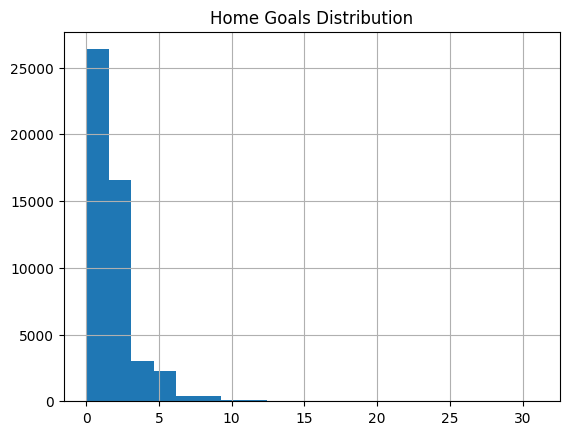

In [29]:
matches_df['home_goals'].hist(bins=20)
plt.title("Home Goals Distribution")
plt.show()

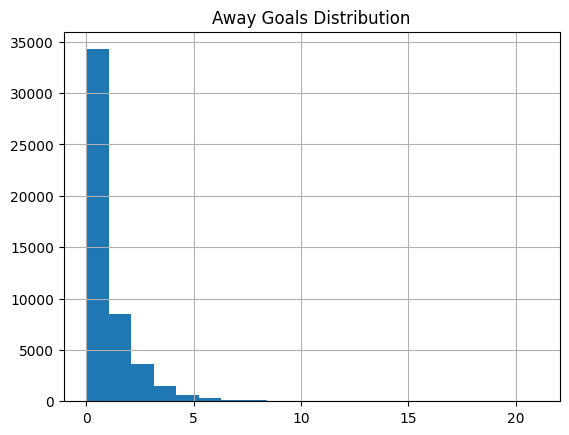

In [30]:
matches_df['away_goals'].hist(bins=20)
plt.title("Away Goals Distribution")
plt.show()

In [39]:
# Validate the Poisson Distribution
print(f"Home Goals mean & Variance{matches_df['home_goals'].mean(), matches_df['home_goals'].var()}")
print(f"Away Goals mean & Variance{matches_df['away_goals'].mean(), matches_df['away_goals'].var()}")


Home Goals mean & Variance(np.float64(1.7570497594250563), 3.1502682814489744)
Away Goals mean & Variance(np.float64(1.182735448768703), 1.9689012145858962)


### Observations
- A peak at 0, 1, or 2 goals i.e Most values are low
- A long tail to the right (few 4, 5, 6 goal games)
- Very few extreme values i.e Few values are high
- Both graphs show Right-skewed poisson distribution. A Poisson distribution models the number of times an event occurs in a fixed interval, given a constant average rate

---

### Evaluating Home Advantage

1. Does playing at home affect team performance?

In [31]:
# Matches played in Neutral ground vs Home/Away matches
matches_df["neutral"].value_counts()

neutral
False    36262
True     12995
Name: count, dtype: int64

In [32]:
matches_df.groupby("neutral")[["home_goals", "away_goals"]].mean()

,home_goals,away_goals
neutral,,
False,1.787601,1.114665
True,1.671797,1.372682


In [ ]:
# EVALUATE MATCH OUTCOME DISTRIBUTION
# ---- Snippet below uses apply() which is slow for large datasets.
# matches_df["result"] = matches_df.apply(
#     lambda x: "home_win" if x['home_goals'] > x['away_goals']
#     else "away_win" if x['home_goals'] < x['away_goals']
#     else "draw",
#     axis=1
# )

# --- BETTER VECTORIZED ALTERNATIVE - np.where() ---
matches_df['result'] = np.where(
    matches_df["home_goals"] > matches_df["away_goals"], "home_win",   # Home win condition 
    np.where(
        matches_df['home_goals'] < matches_df['away_goals'], 'away_win', # Away win condition
        "draw"
    )
)

#
matches_df['result'].value_counts(normalize=True) 

result
home_win    0.489880
away_win    0.282701
draw        0.227419
Name: proportion, dtype: float64

#### Observation

- Home teams score more goals compared to away teams
- More home wins were recorded in the dataset with `48.99%` of Total Game Results. Only `28.27%` of games were won by the away team. `22.74%` were games that ended in draws.

---

#### Evaluating Team Strength

Since some teams may appear more frequently than others e.g Brazil, Germany etc. It is essential to address this issue as the model may bias toward frequently appearing teams we’ll fix this later with Elo ratings

In [34]:
# Evlaluate top 10 most frequent teams in the dataset
matches_df["home_team"].value_counts().head(10)

home_team
Brazil           612
Argentina        603
Mexico           599
Germany          553
South Korea      549
England          548
France           536
Sweden           533
Hungary          497
United States    497
Name: count, dtype: int64

---

#### Time Trends

Concept: Non-Stationarity. Data changes over time

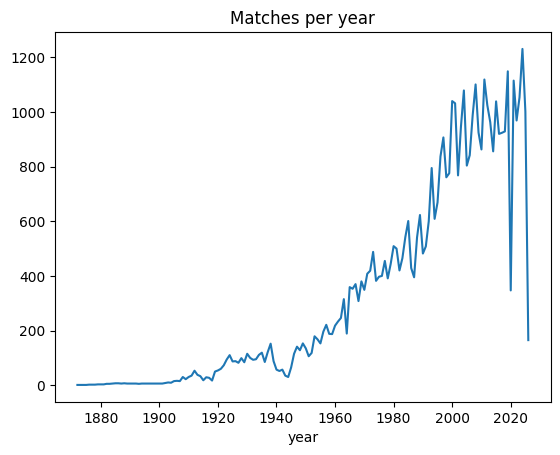

In [35]:
matches_df["year"] = matches_df['date'].dt.year

matches_df.groupby('year').size().plot()
plt.title("Matches per year")
plt.show()

### Observation

- More matches in modern era
- Stronger teams evolve
- Your data is NOT IID

In theory (from your course):
- Models assume data is Independent & Identically Distributed

But here:

- Matches are sequential
- Teams evolve
- Results depend on past

👉 This is why: An Elo system is needed later

---

#### Evaluate Goal Difference

<Axes: >

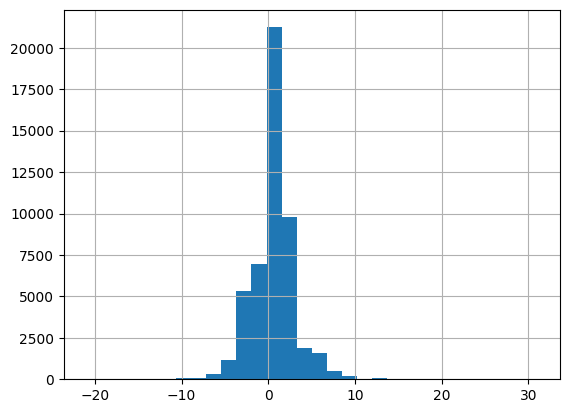

In [36]:
matches_df['goal_diff'] = matches_df["home_goals"] - matches_df["away_goals"]
matches_df["goal_diff"].hist(bins=30)

In [ ]:
# Average Goals Per Match AKA Baseline Scoring Rate(important for poisson later)
(matches_df["home_goals"] + matches_df["away_goals"]).mean()

np.float64(2.939785208193759)

### EDA Insights

1. Goals roughly follow Poisson
2. Home advantage exists
3. Data is time-dependent
4. Teams vary in strength
5. Outcomes are imbalanced

Concept|Inference
---|---
Distribution|Poisson
Bias|Home Advantage
Time Effects|Non-stationarity
Feature Intuition|Goal Difference
